# Evaluación de modelos tabulares (monthly / annual)

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.eda import load_processed_dataset, load_tiff_as_dataarray
from src.training.train import load_trained_pipeline
from src.evaluation.regression import (
    compute_global_regression_metrics,
    compute_pixel_regression_metrics,
    summarize_pixel_metrics,
    rank_best_and_worst_pixels,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# CONFIGURACIÓN
MAIN_DIR = Path("/home/dani/github/profecia/data")
PROCESSED_BASE_DIR = MAIN_DIR / "processed"
SPLITS_BASE_DIR = MAIN_DIR / "splits"
MODELS_BASE_DIR = MAIN_DIR / "models"

temporal_resolution = "annual"   # "monthly" o "annual"
split_type = "landcover"         # "landcover" o "climate"
model_run_name = "annual_landcover_rf"

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

PROCESSED_DIR = PROCESSED_BASE_DIR / temporal_resolution
INPUT_DIR = SPLITS_BASE_DIR / temporal_resolution / split_type 
MODELS_DIR = MODELS_BASE_DIR / temporal_resolution / split_type

MODEL_PATH = MODELS_DIR / f"{model_run_name}_model.joblib"
SCALER_PATH = MODELS_DIR / f"{model_run_name}_scaler.joblib"
TRAIN_INFO_PATH = MODELS_DIR / f"{model_run_name}_train_info.json"

CLIMATE_TIFF = Path("/home/dani/github/profecia/data/masks/climate") /"Beck_KG_V1_present_0p5_5climates.tif"
LANDCOVER_TIFF = Path("/home/dani/github/profecia/data/masks/landcover") / "GLASS-GLC_7classes_2000_0p5_dominant.tif"

print("PROCESSED_DIR:", PROCESSED_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("MODEL_PATH exists:", MODEL_PATH.exists())
print("SCALER_PATH exists:", SCALER_PATH.exists())
print("TRAIN_INFO_PATH exists:", TRAIN_INFO_PATH.exists())

PROCESSED_DIR: /home/dani/github/profecia/data/processed/annual
INPUT_DIR: /home/dani/github/profecia/data/splits/annual/landcover
MODELS_DIR: /home/dani/github/profecia/data/models/annual/landcover
MODEL_PATH exists: True
SCALER_PATH exists: False
TRAIN_INFO_PATH exists: True


In [3]:
macro_labels = {
    0: "NoData",
    1: "Tropical",
    2: "Arid",
    3: "Temperate",
    4: "Cold",
    5: "Polar"
}

lc_labels = {
    0: "NoData",
    10: "Cropland",
    20: "Forest",
    30: "Grassland",
    40: "Shrubland",
    70: "Tundra",
    90: "Barren land",
    100: "Snow/Ice"
}

## Cargar dataset procesado para recuperar grid, LAI y coordenadas

In [4]:
data_dict, metadata = load_processed_dataset(
    input_dir=PROCESSED_DIR,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

lai = data_dict["LAI"]
predictor_names = [v for v in VARIABLE_NAMES if v != "LAI"]

print("Variables cargadas:", list(data_dict.keys()))
print("Shape LAI:", lai.shape)
print("Dims LAI:", lai.dims)
print("Tiempo:", str(pd.to_datetime(lai.time.values[0]))[:10], "->", str(pd.to_datetime(lai.time.values[-1]))[:10])
print("Latitud:", float(lai.latitude.min()), "->", float(lai.latitude.max()))
print("Longitud:", float(lai.longitude.min()), "->", float(lai.longitude.max()))

Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']
Shape LAI: (41, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Tiempo: 1982-01-01 -> 2022-01-01
Latitud: -90.0 -> 89.5
Longitud: -180.0 -> 179.5


## Cargar arrays de test exportados por el split

In [5]:
X_test = np.load(INPUT_DIR / "X_test.npy", mmap_mode="r")
y_test = np.load(INPUT_DIR / "y_test.npy", mmap_mode="r")
pixel_id_test = np.load(INPUT_DIR / "pixel_id_test.npy", mmap_mode="r")
lat_idx_test = np.load(INPUT_DIR / "lat_idx_test.npy", mmap_mode="r")
lon_idx_test = np.load(INPUT_DIR / "lon_idx_test.npy", mmap_mode="r")
time_idx_test = np.load(INPUT_DIR / "time_idx_test.npy", mmap_mode="r")

with open(INPUT_DIR / "dataset_metadata.json", "r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("n test samples:", len(y_test))
print("n unique test pixels:", len(np.unique(pixel_id_test)))
print("temporal_resolution_inferred:", dataset_metadata.get("temporal_resolution_inferred"))

X_test: (52300, 6) float32
y_test: (52300,) float32
n test samples: 52300
n unique test pixels: 1282
temporal_resolution_inferred: annual


## Cargar modelo y scaler

In [6]:
with open(TRAIN_INFO_PATH, "r", encoding="utf-8") as f:
    train_info = json.load(f)

scaler_path = train_info.get("scaler_path")
scaler_path = Path(scaler_path) if scaler_path is not None else None

model, scaler = load_trained_pipeline(
    model_path=MODEL_PATH,
    scaler_path=scaler_path,
)

print("Modelo:", train_info.get("model_name"))
print("Scaler:", train_info.get("scaler_name"))
print("Target:", train_info.get("target"))
print("Feature names:", train_info.get("feature_names"))

Modelo: RandomForestRegressor
Scaler: none
Target: LAI
Feature names: ['SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']


## Transformar test si procede y predecir

In [7]:
if scaler is not None:
    X_test_used = scaler.transform(X_test)
    X_test_used = X_test_used.astype(np.float32, copy=False)
else:
    X_test_used = X_test

y_pred = model.predict(X_test_used)
y_pred = np.asarray(y_pred).reshape(-1)

print("Predicciones:", y_pred.shape)

Predicciones: (52300,)


## Métricas globales

In [8]:
global_metrics = compute_global_regression_metrics(
    y_true=y_test,
    y_pred=y_pred,
)

global_metrics

{'r2': 0.8623480004612113,
 'rmse': 0.4686707853912466,
 'mae': 0.2842704970544968,
 'n_samples': 52300}

## Scatter global real vs predicho

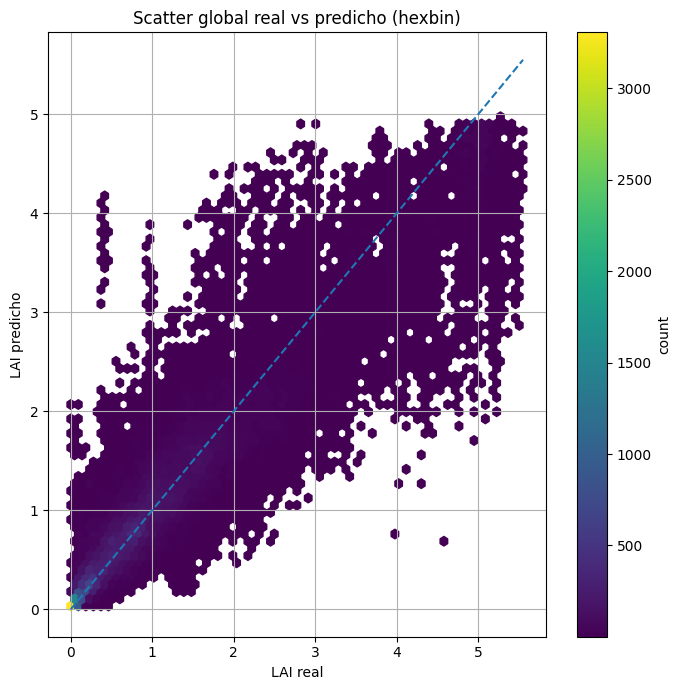

In [9]:
rng = np.random.default_rng(42)
n_plot = min(50000, len(y_test))
idx = rng.choice(len(y_test), size=n_plot, replace=False) if len(y_test) > n_plot else np.arange(len(y_test))

y_true_plot = np.asarray(y_test)[idx]
y_pred_plot = np.asarray(y_pred)[idx]

fig, ax = plt.subplots(figsize=(7, 7))
hb = ax.hexbin(y_true_plot, y_pred_plot, gridsize=60, mincnt=1)
lims = [
    min(np.nanmin(y_true_plot), np.nanmin(y_pred_plot)),
    max(np.nanmax(y_true_plot), np.nanmax(y_pred_plot)),
]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("LAI real")
ax.set_ylabel("LAI predicho")
ax.set_title("Scatter global real vs predicho (hexbin)")
plt.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()

## Métricas por píxel

In [10]:
latitude_per_row = lai.latitude.values[np.asarray(lat_idx_test)]
longitude_per_row = lai.longitude.values[np.asarray(lon_idx_test)]

pixel_metrics_df = compute_pixel_regression_metrics(
    y_true=y_test,
    y_pred=y_pred,
    pixel_id=pixel_id_test,
    lat_idx=lat_idx_test,
    lon_idx=lon_idx_test,
    latitude=latitude_per_row,
    longitude=longitude_per_row,
)

pixel_metrics_df.head()

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,52771,41,-8021.079317,0.192595,0.169039,0.000005,73,211,-53.5,-74.5
1,54210,41,-71024.767707,0.613667,0.577214,0.000005,75,210,-52.5,-75.0
2,54241,41,-55.639544,0.490754,0.459853,0.004252,75,241,-52.5,-59.5
3,55661,41,-37.384568,0.190818,0.125298,0.000949,77,221,-51.5,-69.5
4,58529,41,-3552.839358,0.779203,0.759048,0.000171,81,209,-49.5,-75.5


## Resumen de métricas por píxel

In [11]:
pixel_metrics_summary = summarize_pixel_metrics(pixel_metrics_df)
pixel_metrics_summary

{'n_pixels': 1282,
 'n_pixels_valid_r2': 1267,
 'n_pixels_nan_r2': 15,
 'r2_mean': -4797.3423884345875,
 'r2_median': -9.633633649056605,
 'r2_p05': -1395.8666922591242,
 'r2_p95': -0.3508793993837193,
 'rmse_mean': 0.31636038680745054,
 'rmse_median': 0.21339755323612603,
 'mae_mean': 0.28357708054843694,
 'mae_median': 0.17987867785203987,
 'y_true_variance_mean': 0.00765689573852637,
 'y_true_variance_median': 0.004097521770745516}

## Mejores y peores píxeles por R²

In [12]:
rank_r2 = rank_best_and_worst_pixels(
    pixel_metrics_df=pixel_metrics_df,
    metric="r2",
    top_k=20,
)

best_pixels_r2 = rank_r2["best"]
worst_pixels_r2 = rank_r2["worst"]

display(best_pixels_r2.head(10))
display(worst_pixels_r2.head(10))

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,89876,41,0.501886,0.049631,0.036981,0.004945,124,596,-28.0,118.0
1,97832,41,0.407807,0.068550,0.049452,0.007935,135,632,-22.5,136.0
2,165736,41,0.373081,0.065011,0.052257,0.006742,230,136,25.0,-112.0
3,89163,41,0.366374,0.047804,0.037347,0.003607,123,603,-28.5,121.5
4,98516,41,0.347480,0.068429,0.051885,0.007176,136,596,-22.0,118.0
5,97833,41,0.346549,0.064956,0.050531,0.006457,135,633,-22.5,136.5
6,100473,41,0.277802,0.113074,0.089306,0.017704,139,393,-20.5,16.5
7,90393,41,0.265388,0.019854,0.015888,0.000537,125,393,-27.5,16.5
8,100711,41,0.212352,0.070585,0.051247,0.006325,139,631,-20.5,135.5
9,95442,41,0.199178,0.086933,0.072248,0.009437,132,402,-24.0,21.0


,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,109456,41,-2.288317e+06,1.922257,1.902306,0.000002,152,16,-14.0,-172.0
1,138844,41,-1.127888e+06,2.344758,2.298585,0.000005,192,604,6.0,122.0
2,107256,41,-9.153108e+05,2.021910,1.976286,0.000004,148,696,-16.0,168.0
3,123063,41,-2.832728e+05,1.994018,1.969537,0.000014,170,663,-5.0,151.5
4,143876,41,-2.784934e+05,1.928878,1.901227,0.000013,199,596,9.5,118.0
5,232097,41,-9.247828e+04,0.825160,0.805920,0.000007,322,257,71.0,-51.5
6,126254,41,-7.728544e+04,1.413960,1.314763,0.000026,175,254,-2.5,-53.0
7,54210,41,-7.102477e+04,0.613667,0.577214,0.000005,75,210,-52.5,-75.0
8,128071,41,-6.939533e+04,0.681231,0.657643,0.000007,177,631,-1.5,135.5
9,228543,41,-6.877361e+04,0.630575,0.609657,0.000006,317,303,68.5,-28.5


## Histogramas de métricas por píxel

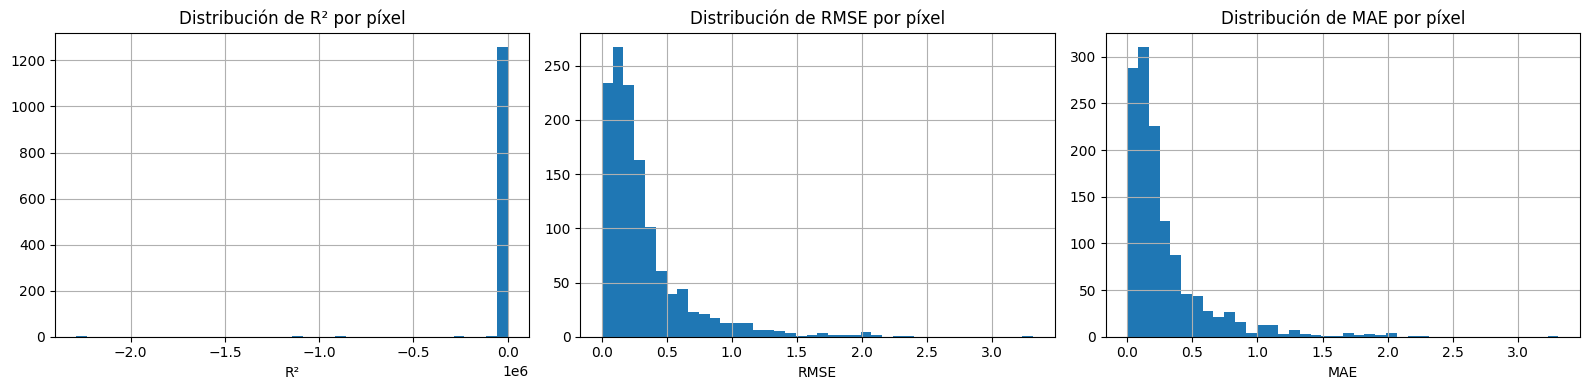

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(pixel_metrics_df["r2"].dropna(), bins=40)
axes[0].set_title("Distribución de R² por píxel")
axes[0].set_xlabel("R²")

axes[1].hist(pixel_metrics_df["rmse"].dropna(), bins=40)
axes[1].set_title("Distribución de RMSE por píxel")
axes[1].set_xlabel("RMSE")

axes[2].hist(pixel_metrics_df["mae"].dropna(), bins=40)
axes[2].set_title("Distribución de MAE por píxel")
axes[2].set_xlabel("MAE")

plt.tight_layout()
plt.show()

## Clasificar R² en 4 grupos

In [14]:
pixel_metrics_plot = pixel_metrics_df.copy()

def classify_r2(x):
    if pd.isna(x):
        return "NaN"
    if x < 0:
        return "Negative"
    if x < 0.25:
        return "Poor"
    if x < 0.50:
        return "Medium"
    return "Good"

pixel_metrics_plot["r2_class"] = pixel_metrics_plot["r2"].apply(classify_r2)
pixel_metrics_plot["r2_class"].value_counts(dropna=False)

r2_class
Negative    1243
Poor          16
NaN           15
Medium         7
Good           1
Name: count, dtype: int64

## Cargar máscaras de clima y land cover

In [15]:
climate_mask = load_tiff_as_dataarray(
    tiff_path=CLIMATE_TIFF,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
    name="climate_mask",
)

landcover_mask = load_tiff_as_dataarray(
    tiff_path=LANDCOVER_TIFF,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
    name="landcover_mask",
)

print(climate_mask.shape, landcover_mask.shape)

(360, 720) (360, 720)


## Añadir clima y land cover a cada píxel

In [16]:
pixel_metrics_plot["climate_code"] = [
    int(climate_mask.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]
pixel_metrics_plot["landcover_code"] = [
    int(landcover_mask.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]

pixel_metrics_plot["climate_label"] = pixel_metrics_plot["climate_code"].map(macro_labels).fillna("Unknown")
pixel_metrics_plot["landcover_label"] = pixel_metrics_plot["landcover_code"].map(lc_labels).fillna("Unknown")

pixel_metrics_plot.head()

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude,r2_class,climate_code,landcover_code,climate_label,landcover_label
0,52771,41,-8021.079317,0.192595,0.169039,0.000005,73,211,-53.5,-74.5,Negative,5,30,Polar,Grassland
1,54210,41,-71024.767707,0.613667,0.577214,0.000005,75,210,-52.5,-75.0,Negative,5,30,Polar,Grassland
2,54241,41,-55.639544,0.490754,0.459853,0.004252,75,241,-52.5,-59.5,Negative,5,30,Polar,Grassland
3,55661,41,-37.384568,0.190818,0.125298,0.000949,77,221,-51.5,-69.5,Negative,2,30,Arid,Grassland
4,58529,41,-3552.839358,0.779203,0.759048,0.000171,81,209,-49.5,-75.5,Negative,5,30,Polar,Grassland


# Análisis por land cover

In [17]:
landcover_summary = (
    pixel_metrics_plot
    .groupby(["landcover_code", "landcover_label", "r2_class"])
    .size()
    .reset_index(name="n_pixels")
)

landcover_total = (
    pixel_metrics_plot
    .groupby(["landcover_code", "landcover_label"])
    .size()
    .reset_index(name="n_total")
)

landcover_summary = landcover_summary.merge(
    landcover_total,
    on=["landcover_code", "landcover_label"],
    how="left",
)

landcover_summary["pct"] = 100 * landcover_summary["n_pixels"] / landcover_summary["n_total"]
landcover_summary.head()

,landcover_code,landcover_label,r2_class,n_pixels,n_total,pct
0,10,Cropland,Negative,121,121,100.000000
1,20,Forest,Negative,400,401,99.750623
2,20,Forest,Poor,1,401,0.249377
3,30,Grassland,Negative,223,226,98.672566
4,30,Grassland,Poor,3,226,1.327434


In [18]:
landcover_summary_round = (
    landcover_summary
    .pivot(index=["landcover_code", "landcover_label"], columns="r2_class", values="pct")
    .fillna(0)
    .reset_index()
)

for c in ["Negative", "Poor", "Medium", "Good", "NaN"]:
    if c not in landcover_summary_round.columns:
        landcover_summary_round[c] = 0.0

landcover_summary_round = landcover_summary_round.sort_values("landcover_code")
landcover_summary_round.head()

r2_class,landcover_code,landcover_label,Good,Medium,NaN,Negative,Poor
0,10,Cropland,0.000000,0.000000,0.0,100.000000,0.000000
1,20,Forest,0.000000,0.000000,0.0,99.750623,0.249377
2,30,Grassland,0.000000,0.000000,0.0,98.672566,1.327434
3,40,Shrubland,0.740741,1.481481,0.0,93.333333,4.444444
4,70,Tundra,0.000000,0.000000,0.0,100.000000,0.000000


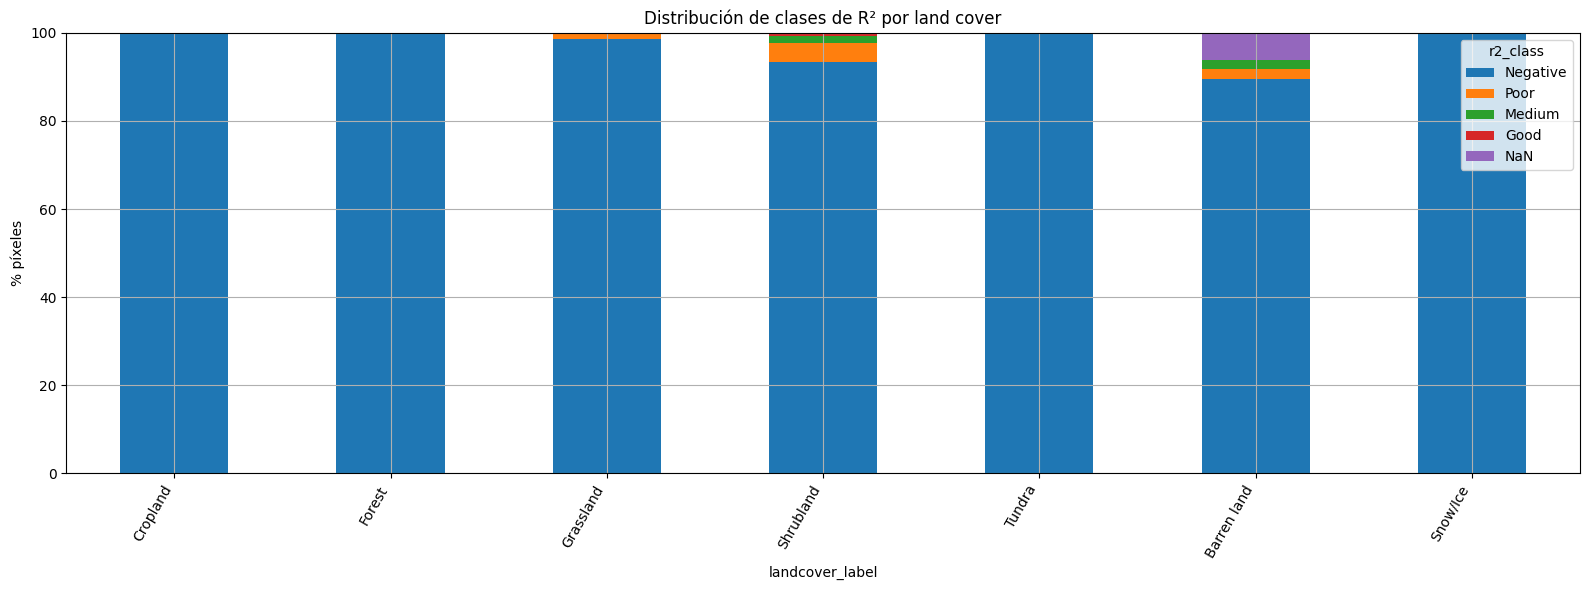

In [19]:
plot_df = landcover_summary_round.set_index("landcover_label")[["Negative", "Poor", "Medium", "Good", "NaN"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(16, 6))
ax.set_ylabel("% píxeles")
ax.set_title("Distribución de clases de R² por land cover")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Análisis por clima

In [20]:
climate_summary = (
    pixel_metrics_plot
    .groupby(["climate_code", "climate_label", "r2_class"])
    .size()
    .reset_index(name="n_pixels")
)

climate_total = (
    pixel_metrics_plot
    .groupby(["climate_code", "climate_label"])
    .size()
    .reset_index(name="n_total")
)

climate_summary = climate_summary.merge(
    climate_total,
    on=["climate_code", "climate_label"],
    how="left",
)

climate_summary["pct"] = 100 * climate_summary["n_pixels"] / climate_summary["n_total"]
climate_summary.head()

,climate_code,climate_label,r2_class,n_pixels,n_total,pct
0,0,NoData,Negative,20,20,100.000000
1,1,Tropical,Negative,214,214,100.000000
2,2,Arid,Good,1,375,0.266667
3,2,Arid,Medium,7,375,1.866667
4,2,Arid,NaN,15,375,4.000000


In [21]:
climate_summary_round = (
    climate_summary
    .pivot(index=["climate_code", "climate_label"], columns="r2_class", values="pct")
    .fillna(0)
    .reset_index()
)

for c in ["Negative", "Poor", "Medium", "Good", "NaN"]:
    if c not in climate_summary_round.columns:
        climate_summary_round[c] = 0.0

climate_summary_round = climate_summary_round.sort_values("climate_code")
climate_summary_round.head()

r2_class,climate_code,climate_label,Good,Medium,NaN,Negative,Poor
0,0,NoData,0.000000,0.000000,0.0,100.000000,0.000000
1,1,Tropical,0.000000,0.000000,0.0,100.000000,0.000000
2,2,Arid,0.266667,1.866667,4.0,90.133333,3.733333
3,3,Temperate,0.000000,0.000000,0.0,99.315068,0.684932
4,4,Cold,0.000000,0.000000,0.0,99.752475,0.247525


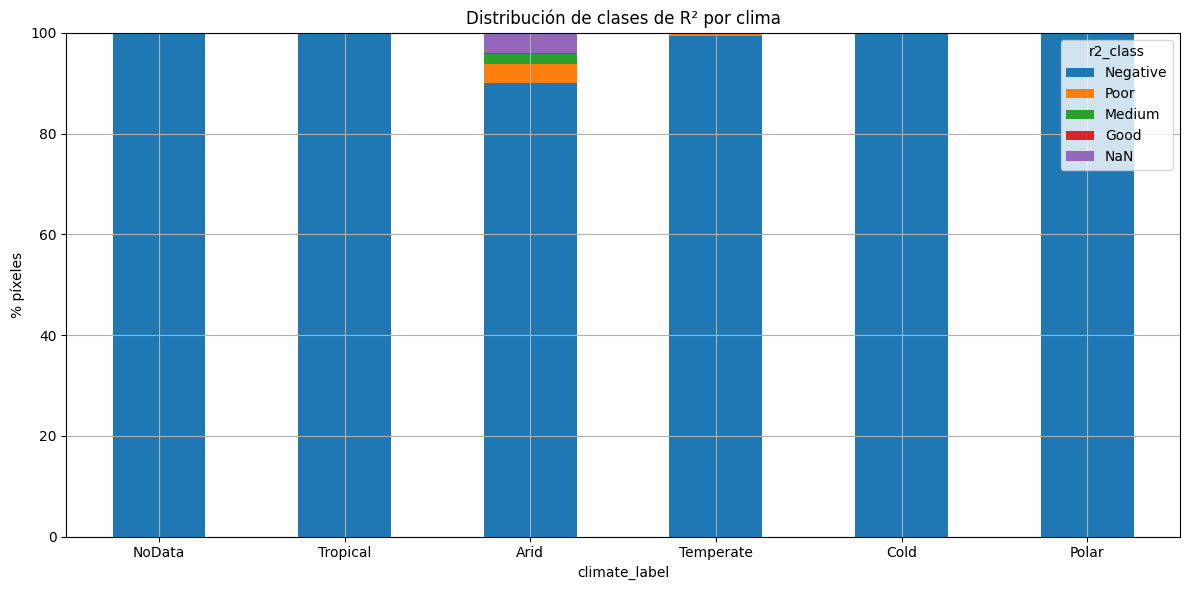

In [22]:
plot_df = climate_summary_round.set_index("climate_label")[["Negative", "Poor", "Medium", "Good", "NaN"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_ylabel("% píxeles")
ax.set_title("Distribución de clases de R² por clima")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de R² vs varianza temporal de LAI

In [23]:
lai_var_map = lai.var(dim="time", skipna=True)
lai_std_map = lai.std(dim="time", skipna=True)

pixel_metrics_plot["lai_var"] = [
    float(lai_var_map.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]
pixel_metrics_plot["lai_std"] = [
    float(lai_std_map.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]

pixel_metrics_plot[["pixel_id", "r2", "lai_var", "lai_std"]].head()

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,pixel_id,r2,lai_var,lai_std
0,52771,-8021.079317,0.000005,0.002150
1,54210,-71024.767707,0.000005,0.002303
2,54241,-55.639544,0.004252,0.065208
3,55661,-37.384568,0.000949,0.030799
4,58529,-3552.839358,0.000171,0.013071


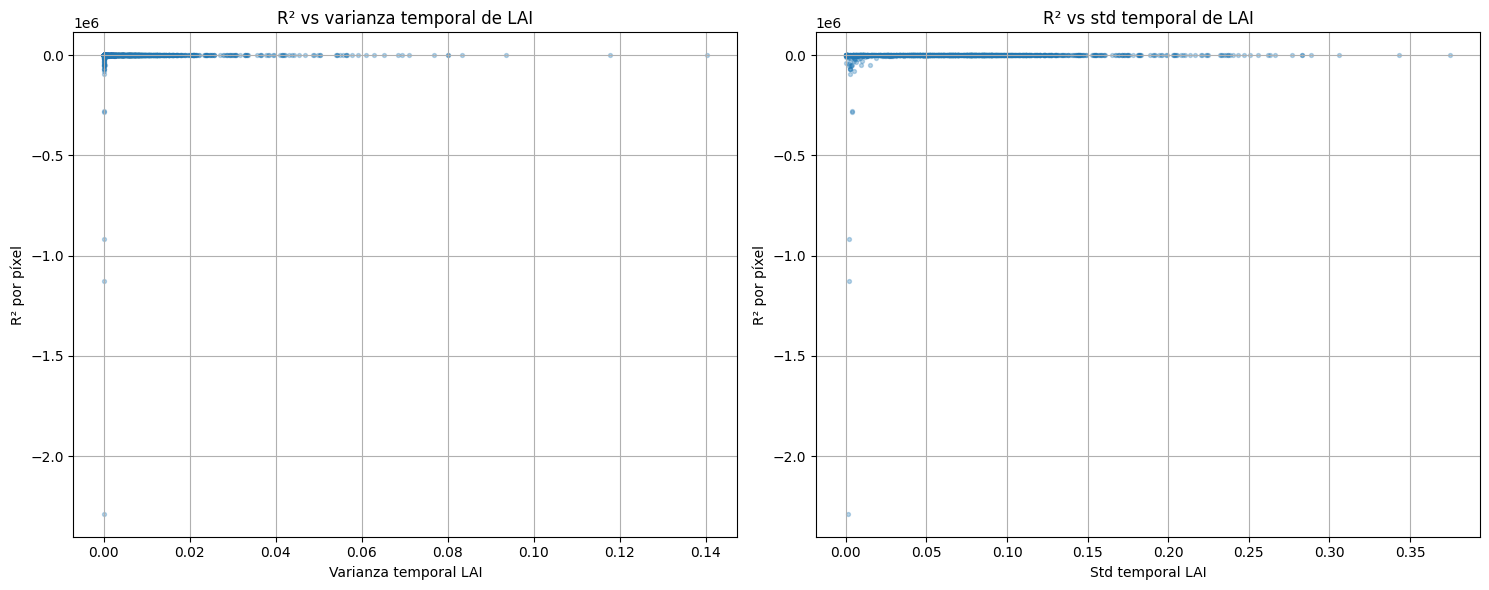

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(pixel_metrics_plot["lai_var"], pixel_metrics_plot["r2"], s=8, alpha=0.3)
axes[0].set_xlabel("Varianza temporal LAI")
axes[0].set_ylabel("R² por píxel")
axes[0].set_title("R² vs varianza temporal de LAI")

axes[1].scatter(pixel_metrics_plot["lai_std"], pixel_metrics_plot["r2"], s=8, alpha=0.3)
axes[1].set_xlabel("Std temporal LAI")
axes[1].set_ylabel("R² por píxel")
axes[1].set_title("R² vs std temporal de LAI")

plt.tight_layout()
plt.show()

## Construir DataFrame de test con trazabilidad temporal

In [25]:
time_values = pd.to_datetime(dataset_metadata["time_values"])

test_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(y_pred),
    "pixel_id": np.asarray(pixel_id_test).astype(np.int64),
    "lat_idx": np.asarray(lat_idx_test).astype(np.int32),
    "lon_idx": np.asarray(lon_idx_test).astype(np.int32),
    "time_idx": np.asarray(time_idx_test).astype(np.int32),
})

test_df["time"] = time_values[test_df["time_idx"].values]
test_df["latitude"] = lai.latitude.values[test_df["lat_idx"].values]
test_df["longitude"] = lai.longitude.values[test_df["lon_idx"].values]
test_df["residual"] = test_df["y_true"] - test_df["y_pred"]
test_df.head()

,y_true,y_pred,pixel_id,lat_idx,lon_idx,time_idx,time,latitude,longitude,residual
0,0.863889,1.058541,52771,73,211,0,1982-01-01,-53.5,-74.5,-0.194652
1,0.375926,1.323100,54210,75,210,0,1982-01-01,-52.5,-75.0,-0.947174
2,0.664815,1.161654,54241,75,241,0,1982-01-01,-52.5,-59.5,-0.496839
3,0.299074,0.581454,55661,77,221,0,1982-01-01,-51.5,-69.5,-0.282379
4,0.863889,1.067563,52771,73,211,1,1983-01-01,-53.5,-74.5,-0.203674


## Density scatters de los 4 mejores y 4 peores píxeles

In [26]:
top4_best = best_pixels_r2.head(4).copy()
top4_worst = worst_pixels_r2.head(4).copy()

selected_pixels_density = pd.concat([
    top4_best.assign(group="best"),
    top4_worst.assign(group="worst"),
], ignore_index=True)

selected_pixels_density[["group", "pixel_id", "r2", "rmse", "mae"]]

,group,pixel_id,r2,rmse,mae
0,best,89876,5.018864e-01,0.049631,0.036981
1,best,97832,4.078069e-01,0.068550,0.049452
2,best,165736,3.730807e-01,0.065011,0.052257
3,best,89163,3.663735e-01,0.047804,0.037347
4,worst,109456,-2.288317e+06,1.922257,1.902306
5,worst,138844,-1.127888e+06,2.344758,2.298585
6,worst,107256,-9.153108e+05,2.021910,1.976286
7,worst,123063,-2.832728e+05,1.994018,1.969537


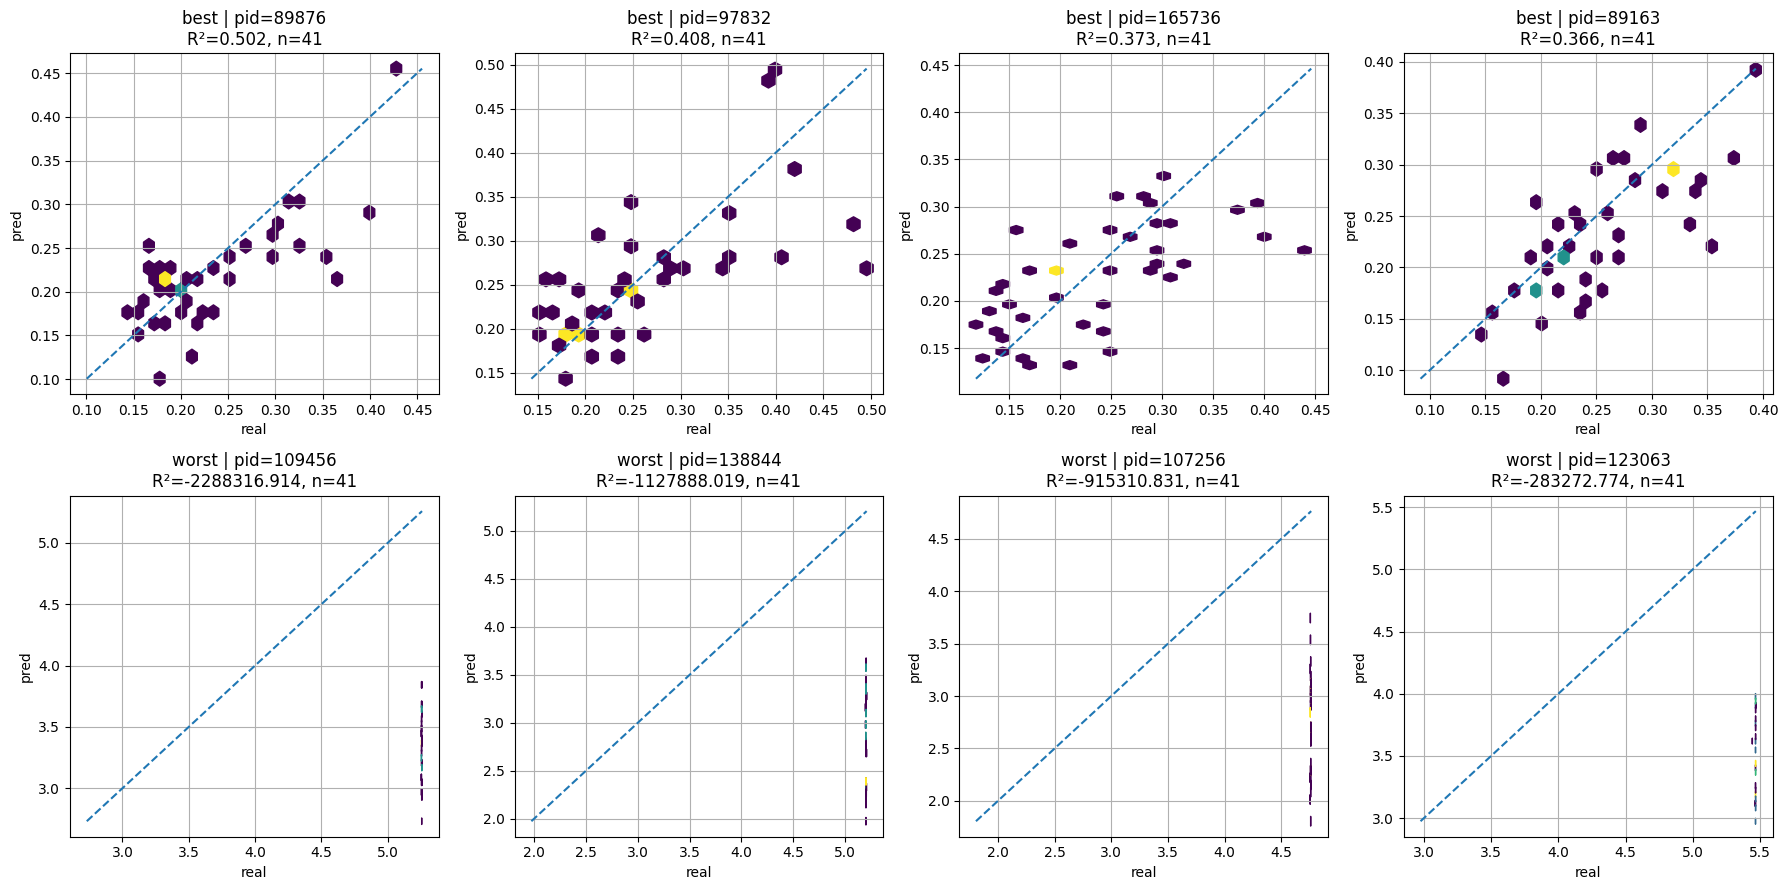

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels_density.iterrows()):
    pid = int(row["pixel_id"])
    sub = test_df[test_df["pixel_id"] == pid].copy()

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    hb = ax.hexbin(sub["y_true"], sub["y_pred"], gridsize=25, mincnt=1)
    lims = [
        min(sub["y_true"].min(), sub["y_pred"].min()),
        max(sub["y_true"].max(), sub["y_pred"].max()),
    ]
    ax.plot(lims, lims, linestyle="--")
    ax.set_title(
        f"{row['group']} | pid={pid}\nR²={row['r2']:.3f}, n={int(row['n_samples'])}"
    )
    ax.set_xlabel("real")
    ax.set_ylabel("pred")

plt.tight_layout()
plt.show()

## Series temporales real vs predicha de los 4 mejores y 4 peores píxeles

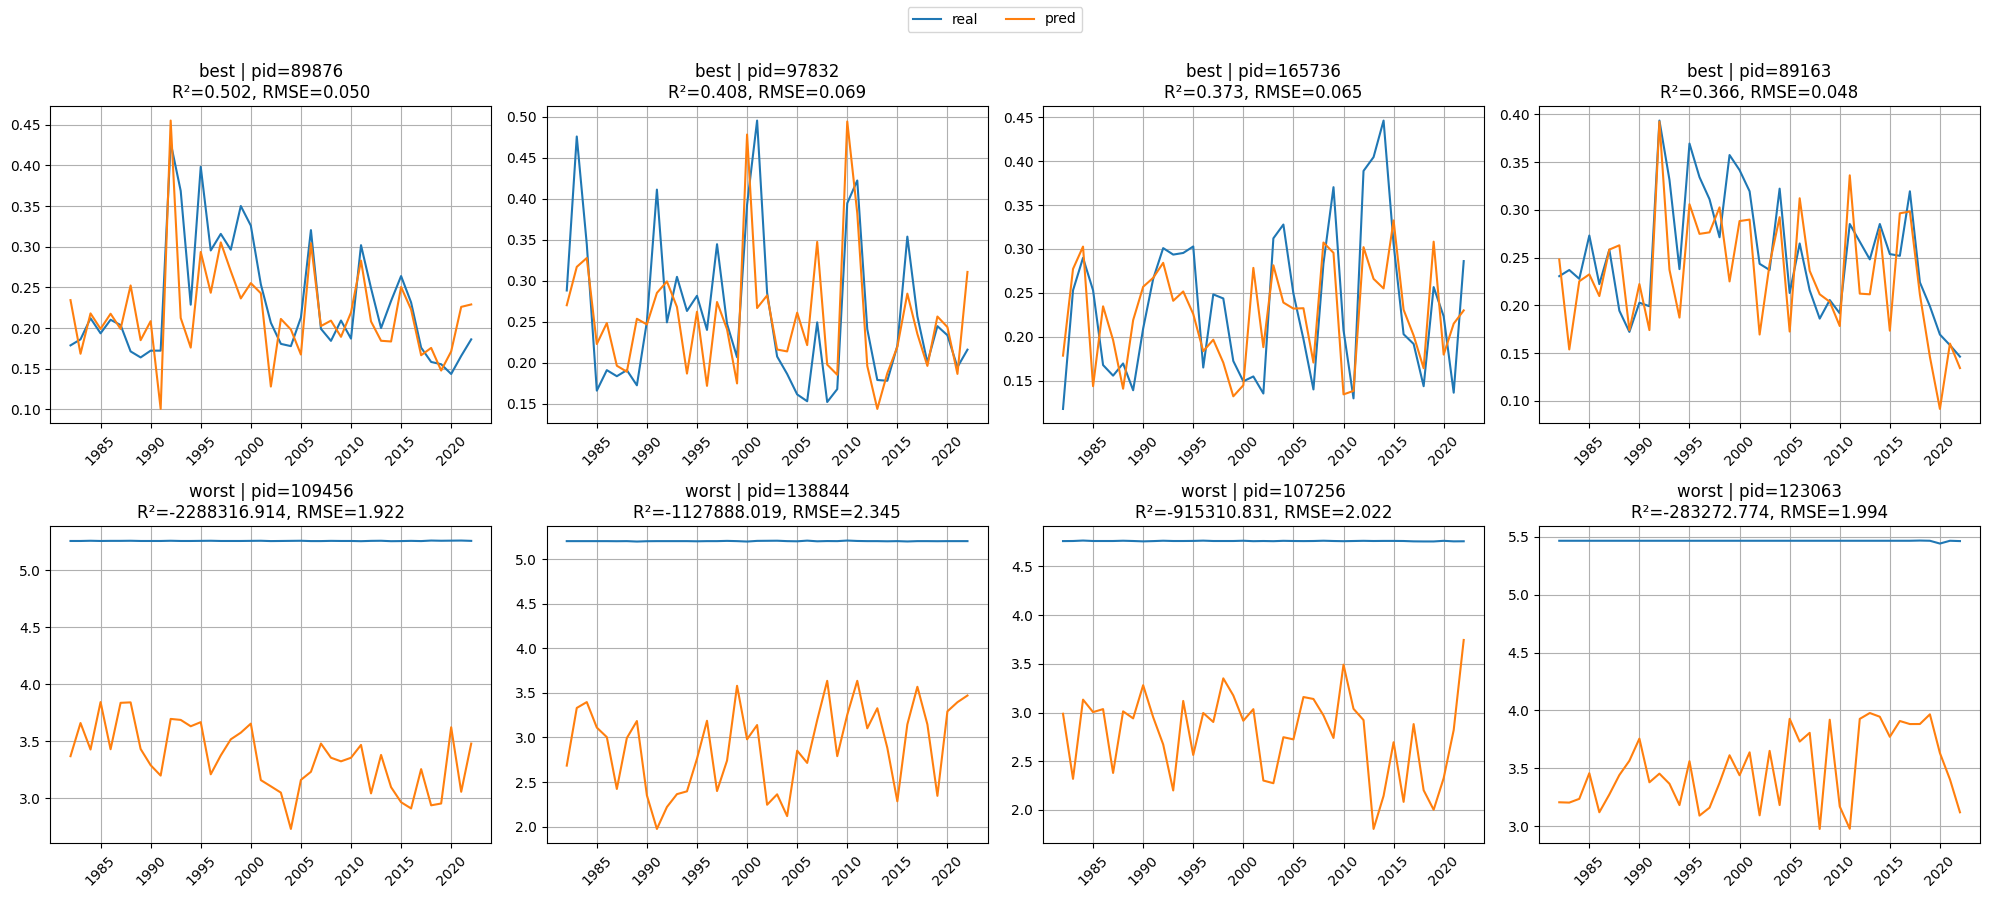

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels_density.iterrows()):
    pid = int(row["pixel_id"])
    sub = test_df[test_df["pixel_id"] == pid].copy().sort_values("time")

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    ax.plot(sub["time"], sub["y_true"], label="real")
    ax.plot(sub["time"], sub["y_pred"], label="pred")
    ax.set_title(
        f"{row['group']} | pid={pid}\nR²={row['r2']:.3f}, RMSE={row['rmse']:.3f}"
    )
    ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Tablas de apoyo: 4 mejores y 4 peores con coordenadas

In [29]:
display(top4_best[["pixel_id", "n_samples", "r2", "rmse", "mae", "lat_idx", "lon_idx", "latitude", "longitude"]])
display(top4_worst[["pixel_id", "n_samples", "r2", "rmse", "mae", "lat_idx", "lon_idx", "latitude", "longitude"]])

,pixel_id,n_samples,r2,rmse,mae,lat_idx,lon_idx,latitude,longitude
0,89876,41,0.501886,0.049631,0.036981,124,596,-28.0,118.0
1,97832,41,0.407807,0.068550,0.049452,135,632,-22.5,136.0
2,165736,41,0.373081,0.065011,0.052257,230,136,25.0,-112.0
3,89163,41,0.366374,0.047804,0.037347,123,603,-28.5,121.5


,pixel_id,n_samples,r2,rmse,mae,lat_idx,lon_idx,latitude,longitude
0,109456,41,-2.288317e+06,1.922257,1.902306,152,16,-14.0,-172.0
1,138844,41,-1.127888e+06,2.344758,2.298585,192,604,6.0,122.0
2,107256,41,-9.153108e+05,2.021910,1.976286,148,696,-16.0,168.0
3,123063,41,-2.832728e+05,1.994018,1.969537,170,663,-5.0,151.5
